# Visualizing the Distribution of Comment Predictions

This notebook demonstrates how to visualize the distribution of comments across different prediction categories using a count plot. The goal is to map numerical predictions to human-readable categories and assign specific colors to each category for better visualization.

## Steps:

1. **Load Dataset**: Load the dataset containing comments and their predicted labels.
2. **Map Predictions to Categories**: Convert numerical predictions into readable categories.
3. **Define Colors**: Assign specific colors to each prediction category.
4. **Create Count Plot**: Visualize the distribution of comments across the prediction categories using a count plot. 

By following these steps, we can gain insights into the relative frequency of each comment category, helping to understand the distribution of opinions or sentiments in the dataset.

In [25]:
import pandas as pd

In [27]:
df_label=pd.read_csv("FinalLabels.csv")

In [31]:
df_label.head(5)
print(len(df_label),len(df))

3061 368313


In [ ]:
df = pd.read_csv("cleaned_data/final_commments_fr_vape_match_with_predictions.csv")
df.head(5)

In [36]:
comments_to_remove = set(df_label['comment'])

# Filtrer df pour exclure les commentaires présents dans comments_to_remove
filtered_df = df[~df['comment'].isin(comments_to_remove)]

output_path = "filtered_df.csv"
filtered_df.to_csv(output_path, index=False)

filtered_df.head(5)

,video_id,comment_id,author,author_profile_image_url,author_channel_url,author_channel_id,comment,published_at,updated_at,like_count,viewer_rating,can_rate,is_reply,parent_id,channel_id,language,language_langdetect,label_predicted
0,BaB4LEZFipU,UgxPR0_IDmNKSqtoqEF4AaABAg,@bouhschnou,https://yt3.ggpht.com/ytc/AIdro_nmrgOj8FjLrysO...,http://www.youtube.com/@bouhschnou,UCNDd8CfcrNHQvpxOHmgoJtw,@14:50 en faisant soi-même son mélange (nicoti...,2023-12-27 14:22:12+00:00,2023-12-27T14:22:12Z,0.0,none,True,False,NaN,UCp2kK3DyhpgFOdILF3BBC9A,fr,NaN,1
1,9UAKK7SPklc,Ugy2HM-9ljEgGGK-uGF4AaABAg,@maverickmike4459,https://yt3.ggpht.com/ytc/AIdro_lK6O2W2e3JHV4f...,http://www.youtube.com/@maverickmike4459,UC3XgmZT7yZoO2z3j34h0ZKQ,lol on parle d écologie sur une clope mais ...,2023-12-15 05:47:52+00:00,2023-12-15T05:47:52Z,0.0,none,True,False,NaN,UCYpRDnhk5H8h16jpS84uqsA,fr,NaN,1
2,9UAKK7SPklc,UgwhQUcSfwqFrk1Yx1N4AaABAg,@orevwar5452,https://yt3.ggpht.com/xuXb8yKJ1sOkZjnlYppfl8-N...,http://www.youtube.com/@orevwar5452,UCXASwJZkETZYFWKl2tYulKg,Ça fait depuis 10ans que ça existent..,2023-12-13 21:02:34+00:00,2023-12-13T21:02:34Z,0.0,none,True,False,NaN,UCYpRDnhk5H8h16jpS84uqsA,fr,NaN,1
3,9UAKK7SPklc,Ugy-rE7KrWwj9OIoGkp4AaABAg,@aspirateur2000,https://yt3.ggpht.com/DWhiaCOTbJxmLUDLAVQbu3B8...,http://www.youtube.com/@aspirateur2000,UCcvjVnHe3e1bKZWLlI1MfmQ,Reste juste la question principale qui est: es...,2023-12-12 22:10:15+00:00,2023-12-12T22:11:03Z,2.0,none,True,False,NaN,UCYpRDnhk5H8h16jpS84uqsA,fr,NaN,2
4,9UAKK7SPklc,UgxqZXypSN0IUQbWold4AaABAg,@alansair4421,https://yt3.ggpht.com/ytc/AIdro_kYk_I7qsC63KqW...,http://www.youtube.com/@alansair4421,UCvNNvEzqGaGdSKT2IMAycPA,Problème de son,2023-12-11 22:19:41+00:00,2023-12-11T22:19:41Z,0.0,none,True,False,NaN,UCYpRDnhk5H8h16jpS84uqsA,fr,NaN,1


C:\Users\Karine\AppData\Local\Temp\ipykernel_14024\3636936188.py:6: DtypeWarning: Columns (9,11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  filtered_df = pd.read_csv("filtered_df.csv")


Index(['video_id', 'comment_id', 'author', 'author_profile_image_url',
       'author_channel_url', 'author_channel_id', 'comment', 'published_at',
       'updated_at', 'like_count', 'viewer_rating', 'can_rate', 'is_reply',
       'parent_id', 'channel_id', 'language', 'language_langdetect',
       'label_predicted'],
      dtype='object')


C:\Users\Karine\AppData\Local\Temp\ipykernel_14024\3636936188.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=filtered_df, x='prediction_category', order=['Contrary', 'Inconclusive', 'Favorable'], palette=colors)


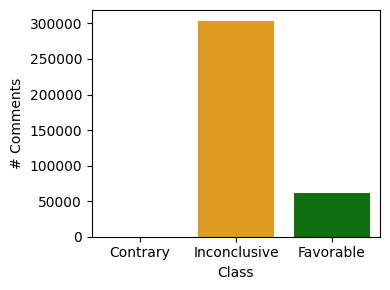

<Figure size 640x480 with 0 Axes>

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Load the dataset
filtered_df = pd.read_csv("filtered_df.csv")

# Vérifiez les colonnes du DataFrame pour vous assurer que 'prediction_category' existe
print(filtered_df.columns)

# Mapping prediction to readable categories
filtered_df['prediction_category'] = filtered_df['label_predicted'].map({0: 'Contrary', 1: 'Inconclusive', 2: 'Favorable'})

# Specific colors for each category
colors = {'Contrary': 'red', 'Inconclusive': 'orange', 'Favorable': 'green'}

# Plot
plt.figure(figsize=(4, 3))
ax = sns.countplot(data=filtered_df, x='prediction_category', order=['Contrary', 'Inconclusive', 'Favorable'], palette=colors)
ax.set_xlabel("Class")
ax.set_ylabel("# Comments")
plt.tight_layout()
plt.show()
plt.savefig('repartition_comments_labels.png')

# Quantifying the Incidence of Three Classes Over Time

This notebook demonstrates how to quantify and visualize the incidence of three classes (favorable, contrary, and inconclusive) in a dataset over time. The dataset contains comments with predicted labels, and we will create a time series plot to show the cumulative number of comments for each class.

## Steps:

1. **Load Dataset**: Load the dataset that contains comments and their predicted labels.
2. **Convert Dates**: Convert the date column to a datetime format.
3. **Filter and Aggregate Comments**: Filter comments by class and aggregate them by date.
4. **Create DataFrame for Plotting**: Create a DataFrame with cumulative counts for each class.
5. **Plot Time Series**: Plot the cumulative time series of comments for each class.


C:\Users\Karine\AppData\Local\Temp\ipykernel_14024\1480059201.py:6: DtypeWarning: Columns (9,11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  filtered_df = pd.read_csv("filtered_df.csv")
C:\Users\Karine\AppData\Local\Temp\ipykernel_14024\1480059201.py:15: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  favorable_comments = df[df['label_predicted'] == 2].groupby(df['published_at'].dt.to_period('M')).size().cumsum()
C:\Users\Karine\AppData\Local\Temp\ipykernel_14024\1480059201.py:16: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  inconclusive_comments = df[df['label_predicted'] == 1].groupby(df['published_at'].dt.to_period('M')).size().cumsum()
C:\Users\Karine\AppData\Local\Temp\ipykernel_14024\1480059201.py:26: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  }).fillna(metho

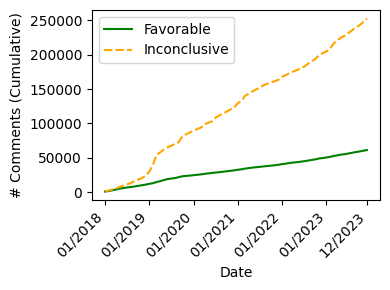

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load the dataset
filtered_df = pd.read_csv("filtered_df.csv")

# Convert dates
filtered_df['published_at'] = pd.to_datetime(filtered_df['published_at'], errors='coerce')  # Coerce errors to NaT

# Drop rows with invalid dates
df = filtered_df.dropna(subset=['published_at'])

# Filter and aggregate favorable and inconclusive comments by date
favorable_comments = df[df['label_predicted'] == 2].groupby(df['published_at'].dt.to_period('M')).size().cumsum()
inconclusive_comments = df[df['label_predicted'] == 1].groupby(df['published_at'].dt.to_period('M')).size().cumsum()

# Reset index to convert PeriodIndex to Timestamp
favorable_comments.index = favorable_comments.index.to_timestamp()
inconclusive_comments.index = inconclusive_comments.index.to_timestamp()

# Create a single DataFrame for plotting
data = pd.DataFrame({
    'Favorable': favorable_comments,
    'Inconclusive': inconclusive_comments
}).fillna(method='ffill')  # Fill NaN values with the last valid value

# Plot the cumulative time series
plt.figure(figsize=(4, 3))
sns.lineplot(data=data, palette={'Favorable': 'green', 'Inconclusive': 'orange'})
plt.xlabel('Date')
plt.ylabel('# Comments (Cumulative)')

# Setting up the x-axis ticks to show the start of each year and the last date in the dataset
unique_years = data.index.year.unique()
tick_positions = []
tick_labels = []

for year in unique_years:
    year_data = data[data.index.year == year]
    first_day = year_data.index.min()
    last_day = year_data.index.max()
    
    # Add the first day of each year
    tick_positions.append(first_day)
    tick_labels.append(first_day.strftime('%m/%Y'))
    
    # For the last year, also add the last day
    if year == unique_years[-1]:
        if last_day != first_day:  # Only add if it's different from the first day
            tick_positions.append(last_day)
            tick_labels.append(last_day.strftime('%m/%Y'))

plt.xticks(tick_positions, tick_labels, rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.savefig("Comments_cumulative_repartition.png")
plt.show()


# Generating Word Clouds for Different Classes with French Stopwords

This notebook demonstrates how to generate word clouds for comments classified into three categories (favorable, inconclusive, and contrary). The word clouds exclude common stopwords in French to highlight the most significant words.

## Steps:

1. **Setup**: Import libraries and ensure necessary resources are available.
2. **Load Dataset**: Load the dataset containing comments and their predicted labels.
3. **Filter Comments**: Filter comments based on their classifications.
4. **Generate Word Clouds**: Create and display word clouds for each class with specific color schemes.

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Karine\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
C:\Users\Karine\AppData\Local\Temp\ipykernel_14024\882637668.py:43: DtypeWarning: Columns (9,11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  filtered_df = pd.read_csv("filtered_df.csv")


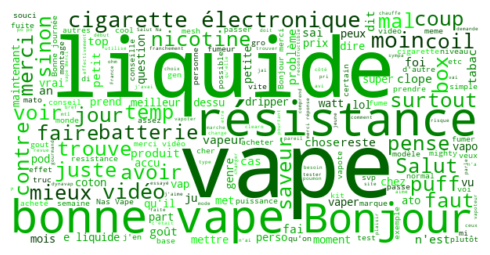

<Figure size 640x480 with 0 Axes>

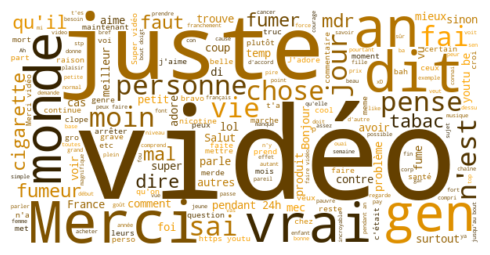

<Figure size 640x480 with 0 Axes>

In [4]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud, get_single_color_func
import pandas as pd
from nltk.corpus import stopwords
import nltk

# Ensure NLTK has the necessary stopwords
nltk.download('stopwords')

# Stopwords in French
stopwords_fr = set(stopwords.words('french'))
custom_stopwords = set([
    'a', 'abandonner', 'à', 'aucun', 'aucune', 'au', 'aussi', 'avant', 'avec', 'bien', 'car', 'ce', 
    'cela', 'ces', 'c’est', 'ça', 'dans', 'de', 'des', 'du', 'dès', 'donc', 'elle', 'en', 'et', 
    'être', 'eux', 'il', 'ils', 'je', 'jusqu’à', 'là', 'le', 'les', 'leur', 'lui', 'ma', 'mais', 
    'me', 'moi', 'mon', 'ne', 'nous', 'on', 'ou', 'par', 'pas', 'pour', 'que', 'quel', 'quelle', 
    'quelles', 'quelques', 'qui', 'sa', 'se', 'ses', 'si', 'son', 'sont', 'sur', 'ta', 'te', 
    'tous', 'tout', 'tu', 'un', 'une', 'vos', 'votre', 'vous', 'y', 'à', 'abord', 'alors', 'autre', 
    'avant', 'bien', 'comme', 'dans', 'd’abord', 'depuis', 'derrière', 'deux', 'donc', 'entre', 
    'ensemble', 'ensuite', 'façon', 'hors', 'je', 'jusqu’à', 'lorsque', 'malgré', 'mais', 'ni', 
    'non', 'nôtre', 'nul', 'parce', 'peu', 'pourquoi', 'près', 'quand', 'sans', 'sous', 'tellement', 
    'très', 'voici', 'voilà', 'auprès', 'afin', 'alors', 'aujourd’hui', 'auquel', 'cela', 'celles', 
    'celui', 'cette', 'd’', 'déjà', 'et', 'être', 'exactement', 'fait', 'jamais', 'leur', 'lorsque', 
    'parmi', 'rien', 'telle', 'tels', 'très', 'voilà', 'absolument', 'alors', 'avec', 'bien', 'bon', 
    'deux', 'encore', 'jamais', 'même', 'néanmoins', 'partout', 'quelque', 'quelquefois', 'trop', 
    'tout', 'toujours', 'très', 'vraiment', 'soit', 'ou', 'aucun', 'autre', 'beaucoup', 'ces', 
    'cet', 'cette', 'd’autre', 'dans', 'enfin', 'également', 'encore', 'même', 'par', 'près', 
    'quel', 'si', 'souvent', 'tous', 'toute', 'vous', 'c\'est', 'j\'ai', 'peut', 'ça', 'va', 'quoi', 
    'puis', 'lui', 'avant', 'en', 'eux', 'que', 'au', 'il', 'nous', 'des', 'cette', 'quand', 'enfin',
    'tout', 'tous', 'lors', 'ainsi', 'car', 'ni', 'dès', 'parmi', 'selon', 'alors', 'ainsi', 'comme',
    'avant', 'donc', 'sauf', 'par', 'au', 'près', 'entre', 'de', 'où', 'après', 'seul', 'avant', 
    'comme', 'sans', 'au', 'auprès', 'cependant', 'lorsque', 'enfin', 'notamment', 'finalement', 
    'afin', 'aussi', 'jusqu’à', 'éventuellement', 'sans', 'si', 'souvent', 'quelque', 'autre', 
    'beaucoup', 'quoi', 'alors', 'toutefois', 'dès', 'sauf', 'malgré', 'notre', 'votre', 'leur', 
    'cette', 'celui', 'cela', 'donc', 'également', 'parmi', 'auprès', 'car', 'même', 'parce', 
    'ainsi', 'très', 'tous', 'autre', 'entre', 'même', 'seul', 'déjà', 'peu', 'beaucoup', 'quelque',
    'au', 'comme', 'avant', 'dès', 'sous', 'quelques', 'certaines', 'd’autres', 'également','plu','ca','plus','oui'
]
)
combined_stopwords = stopwords_fr.union(custom_stopwords)

# Load the dataset
filtered_df = pd.read_csv("filtered_df.csv")

N_TOP_VIDEOS = 1000

# Filter by favorable, inconclusive, and contrary comments, group by video_id, count, and sort
favorable_comments_count = filtered_df[filtered_df['label_predicted'] == 2].groupby('video_id').size().sort_values(ascending=False)
inconclusive_comments_count = filtered_df[filtered_df['label_predicted'] == 1].groupby('video_id').size().sort_values(ascending=False)
contrary_comments_count = filtered_df[filtered_df['label_predicted'] == 0].groupby('video_id').size().sort_values(ascending=False)

# Get the IDs of the top videos with the most favorable, inconclusive, and contrary comments
top_favorable_video_ids = favorable_comments_count.head(N_TOP_VIDEOS).index
top_inconclusive_video_ids = inconclusive_comments_count.head(N_TOP_VIDEOS).index
top_contrary_video_ids = contrary_comments_count.head(N_TOP_VIDEOS).index

class SimpleGroupedColorFunc(object):
    """Create a color function object which assigns EXACT colors to certain words
       based on the position in the list."""
    def __init__(self, color_to_words):
        self.color_to_words = color_to_words

        # Ensure a single color is not associated with two different words
        self.words_to_color = {}
        for (color, words) in color_to_words.items():
            for word in words:
                self.words_to_color[word] = color

    def __call__(self, word, **kwargs):
        return self.words_to_color.get(word, 'black')

def generate_wordcloud(data, color_func):
    # Join all comments into a single string
    text = ' '.join(data)
    # Filter out stopwords
    text = ' '.join([word for word in text.split() if word.lower() not in combined_stopwords])
    # Generate the word cloud
    wordcloud = WordCloud(width=600, height=300, background_color='white', stopwords=combined_stopwords).generate(text)
    plt.figure(figsize=(5, 4))
    plt.imshow(wordcloud.recolor(color_func=color_func, random_state=3), interpolation='bilinear')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Specific colors for each type of comment
green_color_func = get_single_color_func('green')
orange_color_func = get_single_color_func('orange')
red_color_func = get_single_color_func('red')

# Filter comments for top videos with the most favorable, inconclusive, and contrary comments
favorable_comments = df[df['video_id'].isin(top_favorable_video_ids) & (df['label_predicted'] == 2)]['comment']
inconclusive_comments = df[df['video_id'].isin(top_inconclusive_video_ids) & (df['label_predicted'] == 1)]['comment']
contrary_comments = df[df['video_id'].isin(top_contrary_video_ids) & (df['label_predicted'] == 0)]['comment']

# Generate word clouds for favorable comments
generate_wordcloud(favorable_comments, green_color_func)
plt.savefig('green_wordcloud.png')

# Generate word clouds for inconclusive comments
generate_wordcloud(inconclusive_comments, orange_color_func)
plt.savefig('yellow_wordcloud.png')

# # Generate word clouds for contrary comments
# generate_wordcloud(contrary_comments, red_color_func)


### To Do List

- **Analyze Top Users with Favorable Comments**: DONE

Create a CDF (Cumulative Distribution Function) of the number of favorable comments made by users to check if many users make many comments with a specific position.
- **Select Top 5 Videos with Most Favorable Comments**: 

Identify the top 5 videos with the highest absolute number of favorable comments.
- **Be Creative**: 

Use your creativity to explore additional insights or visualizations from the data.


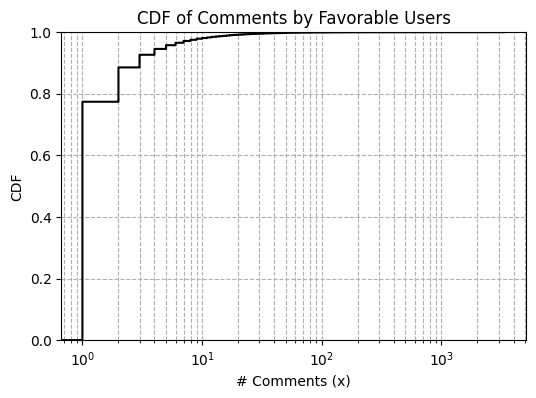

<Figure size 640x480 with 0 Axes>

In [5]:
favorable_df = filtered_df[filtered_df['label_predicted'] == 2]

# Group by author and count the number of comments for each author
favorable_users = favorable_df.groupby('author').size().reset_index(name='num_comments')

# Plot the CDF for the number of comments a channel receives
plt.figure(figsize=(6, 4))
sns.ecdfplot(data=favorable_users, x='num_comments', color='black')
plt.xlabel('# Comments (x)')
plt.ylabel('CDF')
plt.xscale('log')  # Set the x-axis to logarithmic scale
plt.grid(True, which="both", ls="--")
plt.title('CDF of Comments by Favorable Users')
plt.show()
plt.savefig('CDF_comments_favorable_users.png')

In [43]:
import pandas as pd

# Load the dataset


# Filter to include only favorable comments (label_predicted == 2)
favorable_df = filtered_df[filtered_df['label_predicted'] == 2]

# Group by video and count the number of favorable comments for each video
video_comment_counts = favorable_df.groupby('video_id').size().reset_index(name='num_comments')

# Sort the videos by the number of comments in descending order
top_videos = video_comment_counts.sort_values(by='num_comments', ascending=False).head(5)

# Display the top 5 videos with the most favorable comments
print(top_videos)


         video_id  num_comments
4869  lLFsqDM0atQ           420
3729  _a63njvv1P8           363
1152  AlAHiIaEgBY           340
3642  ZhSLxlHFdVE           340
1619  FZytkQzGY6Q           269
